In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchtune.modules import RotaryPositionalEmbeddings
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import autocast, GradScaler
from datasets import load_dataset, load_from_disk
import re
from collections import Counter
import gc
from datasets.pubmed_pipeline import get_dataloaders, TOKENIZER_NAME
from transformers import AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.version.cuda)
print(f"running on {device}")

13.0
running on cuda


In [ ]:
vocab_size = 0
mask_id = 0
pad_id = 1
unknown_id = 2
min_freq = 0

def collate_fn(batch, pad_id):
    padded = torch.stack(batch)
    padding_mask = (padded == pad_id)
    return padded, padding_mask

collate_id = lambda batch: collate_fn(batch, pad_id)

class CaptionDataset(Dataset):
    def __init__(self, captions, vocab: dict, max_len=32, unknown_id = unknown_id):
        self.captions = captions
        self.vocab    = vocab
        self.max_len  = max_len

        tokens = []
        for cap in captions:
            words = cap.split()[:max_len]
            ids   = [vocab.get(w, unknown_id) for w in words]
            ids  += [pad_id] * (max_len - len(ids))
            tokens.append(ids)

        self.tokens = torch.tensor(tokens, dtype=torch.long) 

    def __len__(self):
        return len(self.captions)

    def __getitem__(self, idx):
        return self.tokens[idx]

try:
    ds = load_from_disk("datasets/facad_dataset")
except:
    ds = load_dataset("Luna288/image-captioning-FACAD-base", split="train")
    ds.save_to_disk("datasets/facad_dataset")
captions = [ex["text"] for ex in ds]

new_captions = []
counts = Counter()
for cap in captions:
    cap = cap.lower()
    cap = re.sub(r"[-/]", " ", cap)
    cap = re.sub(r"[^a-z0-9 ]", "", cap)
    new_captions.append(cap)
    counts.update(cap.split())

captions = new_captions

vocab = {"<mask>": 0, "<pad>": 1, "<unk>": 2}
for word, count in counts.items():
    if count >= min_freq:
        vocab[word] = len(vocab)
    
vocab_size = len(vocab)
print(f"Vocab size: {vocab_size}")

dataset = CaptionDataset(captions, vocab)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_id,
    num_workers=0,
    pin_memory=False,
)

print(captions[:10])

Vocab size: 17224
['flower fall and spot spatter this wear everywhere top cut with a gracefully pleated neckline', 'inspired by classic american style this prepster staple is knit from soft warming wool and sharpened up with colorful stripe and a crisp cotton twill collar', 'pretty floral lace bloom across this cropped camisole that s soft stretchy and comfortable to wear', 'if the sweater is clean so is the crisp white tee to top beneath it thanks to the sweater over tee look of this pullover style that s already paired', 'frilly trim enhances the whimsical appeal of this polka dot blouse fashioned from light luminous silk', 'rich metallic stripe elevate a handsome tie cut from pure silk', 'a high waist cut and a just right stretch combine to create a pair of everyday jeans that fit to flatter with comfort to spare', 'strap in and take the plunge with this satin dress that will make you feel like the life of the party', 'elegantly intricate lace add art deco vibe to a slender sheath d

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
pad_id  = tokenizer.pad_token_id
mask_id = tokenizer.mask_token_id

train_loader, val_loader = get_dataloaders(batch_size=32, num_workers=4)

In [4]:
class MultiHeadAttentionNode(nn.Module):
    def __init__(self, d_model, num_heads, dropout = 0.2):
        assert d_model % num_heads == 0
        super().__init__()

        self.Wqkv = nn.Linear(d_model, 3 * d_model)
        self.Wo = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

        self.num_heads = num_heads
        self.d_head = int(d_model / num_heads)
        self.scale = self.d_head ** 0.5

        self.rope = RotaryPositionalEmbeddings(int(d_model//num_heads))

    def forward(self, x, padding_mask = None):
        B, N, D = x.shape
        QKV = self.Wqkv(x)
        QKV = QKV.view(B, N, 3, self.num_heads, self.d_head)
        QKV = QKV.permute(2, 0, 3, 1, 4)  # (3, B, H, N, d_head)
        Q, K, V = QKV[0], QKV[1], QKV[2]

        Q = Q.permute(0, 2, 1, 3)
        K = K.permute(0, 2, 1, 3)
        Q = self.rope(Q).permute(0, 2, 1, 3)
        K = self.rope(K).permute(0, 2, 1, 3)

        score = (Q @ K.transpose(-2, -1)) # batch H N N
        score = score / self.scale

        if padding_mask is not None:
            # padding_mask is (B, N), need (B, 1, 1, N) to broadcast over heads
            score = score.masked_fill(padding_mask[:, None, None, :], float('-inf'))

        weights = self.dropout(F.softmax(score, dim=-1))
        out = torch.matmul(weights, V) # batch H N d_head

        out = out.transpose(1, 2).contiguous() # B N H d_head
        out = out.view(B, N, D)

        out = self.dropout(self.Wo(out))

        return out, weights

class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_ff, heads, dropout = 0.2):
        super().__init__()
        self.attn = MultiHeadAttentionNode(d_model, heads, dropout=dropout)
        self.ff = nn.Sequential(*[
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            
        ])
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, padding_mask=None):
        x = x + self.dropout(self.attn(self.ln1(x), padding_mask)[0])
        x = x + self.dropout(self.ff(self.ln2(x)))
        return x

class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers):
        super().__init__()

        self.embed = nn.Embedding(vocab_size, d_model)
        self.transformers = nn.ModuleList(
            [TransformerBlock(d_model, d_ff, num_heads) for i in range(num_layers)]
        )
        self.ln = nn.LayerNorm(d_model)

    def forward(self, x, padding_mask = None):
        out = self.embed(x)
        for transformer in self.transformers:
            out = transformer(out, padding_mask)
        norm = self.ln(out)
        return norm
    
class MLMTrainer(nn.Module):
    def __init__(self, encoder: Encoder, encoder_dim, vocab_size, mask_id, dropout = 0.2, mask_ratio = 0.15):
        super().__init__()

        self.encoder = encoder
        self.vocab_size = vocab_size
        self.decoder = nn.Linear(encoder_dim, vocab_size, bias=False)
        self.dropout = nn.Dropout(dropout)
        
        self.mask_ratio = mask_ratio
        self.mask_id = mask_id

        self.decoder.weight = self.encoder.embed.weight

    def mask_tokens(self, x):
        mask = (torch.rand(x.shape, device=x.device) < self.mask_ratio) & (x != pad_id)
        decision_mask = torch.rand(x.shape, device=x.device)
        mask_mask = mask & (decision_mask < 0.8)
        unknown_mask = mask & (decision_mask > 0.8) & (decision_mask < 0.9)
        
        ground = x.clone()
        masked = x.clone()

        masked[mask_mask] = self.mask_id
        masked[unknown_mask] = torch.randint(3, self.vocab_size, masked[unknown_mask].shape, device = device)
        ground[~mask] = -100

        return masked, ground

    def forward(self, x, padding_mask = None):
        masked, ground = self.mask_tokens(x)
        pred = self.encoder(masked, padding_mask)
        return self.decoder(pred), ground

In [5]:
encoding_dim = 512

whereswaldo = Encoder(
    vocab_size=vocab_size,
    d_model=encoding_dim,
    num_heads=8,
    d_ff=4*encoding_dim,
    num_layers=8
).to(device)

whereswaldotrainer = MLMTrainer(
    encoder=whereswaldo,
    encoder_dim=encoding_dim,
    vocab_size=vocab_size,
    mask_id=mask_id
).to(device)

nn.init.normal_(whereswaldo.embed.weight, std=0.02)
optimizer = torch.optim.AdamW(whereswaldotrainer.parameters(), lr = 3e-4, weight_decay=0.1)
loss_fn = F.cross_entropy

start = 0

In [5]:
for batch in tqdm(loader):
    pass

100%|██████████| 1933/1933 [00:00<00:00, 10724.50it/s]


In [ ]:
epochs = 600

scheduler = OneCycleLR(
    optimizer,
    max_lr=3e-4,
    steps_per_epoch=len(loader),
    epochs=epochs,
    pct_start=0.05   # 5% of training is warmup
)

for i in range(start):
    scheduler.step()

scaler = GradScaler(device)

for i in range(start, epochs):
    whereswaldotrainer.train()
    total_loss = 0
    for j, batch in enumerate(loader):
        x = batch["input_ids"].to(device)
        padding_mask = (x == pad_id) 
        x = x.to(device)
        padding_mask = padding_mask.to(device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type = str(device)):
            pred, y = whereswaldotrainer(x, padding_mask)
            loss = loss_fn(
                pred.view(-1, vocab_size),
                y.view(-1)
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(whereswaldotrainer.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        if j % 20 == 0:
            print(f"batch {j}/{len(loader)}: loss = {loss}", end="\r")
        if j % 200 == 0:
            torch.cuda.empty_cache()
            gc.collect()

        total_loss += loss.item()

    print(f"Epoch {i+1}: loss: {total_loss/len(loader)}")
    torch.cuda.empty_cache()
    gc.collect()

KeyboardInterrupt: 

In [7]:
def save_checkpoint(path, model, optimizer, scheduler, scaler, epoch):
    torch.save({
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "epoch": epoch,
    }, path)

def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None):
    ckpt = torch.load(path, map_location=device)
    
    model.load_state_dict(ckpt["model"])
    
    if optimizer:
        optimizer.load_state_dict(ckpt["optimizer"])
    if scheduler:
        scheduler.load_state_dict(ckpt["scheduler"])
    if scaler:
        scaler.load_state_dict(ckpt["scaler"])

    return ckpt["epoch"]
        

# save_checkpoint("trained/MLM.pt", whereswaldotrainer, optimizer, scheduler, scaler, i)
start = load_checkpoint("trained/reconstructed_model.pt", whereswaldotrainer, optimizer, scheduler, scaler)

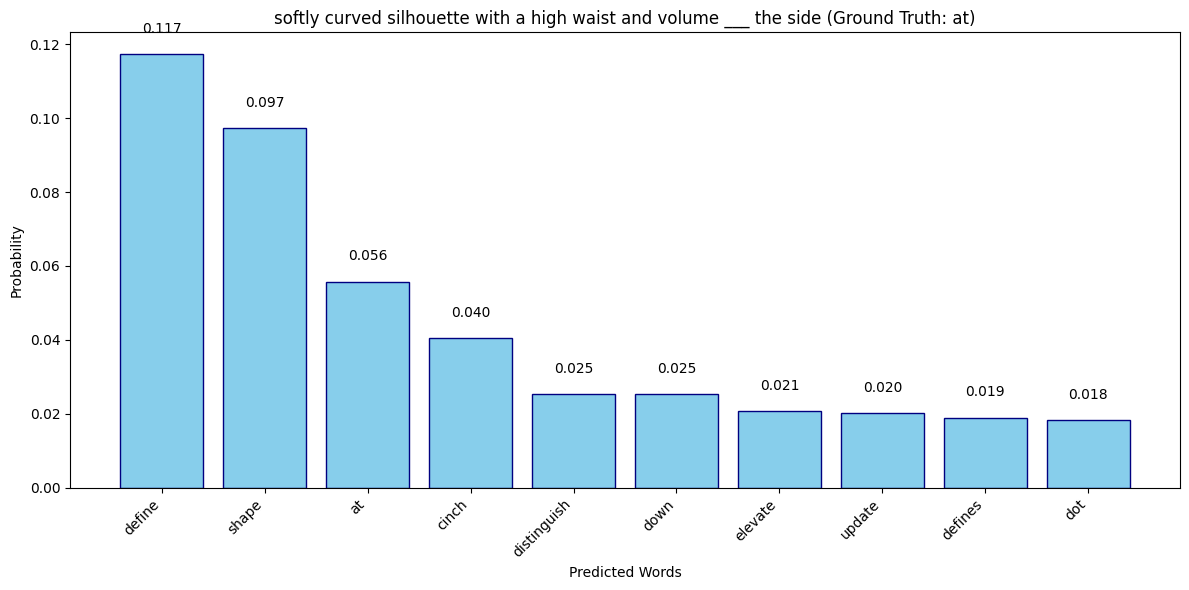

In [36]:
def plot_probe_reconstruction(sentence, model, vocab, mask_num=7, top_k=10):
    model.eval()
    
    # Preprocess and tokenize
    words = sentence.lower().split()
    tokens = [vocab.get(w, 2) for w in words]
    for i, token in enumerate(tokens):
        if token == 2:
            print(words[i])
    
    # Store original for ground truth
    original_word = words[mask_num]
    
    # Apply mask
    masked_tokens = tokens[:]
    masked_tokens[mask_num] = 0  # <mask_id> is 0 in your notebook
    
    # Convert to tensor and move to same device as model
    input_tensor = torch.tensor([masked_tokens]).to(next(model.parameters()).device)
    
    with torch.no_grad():
        # Forward pass: whereswaldotrainer returns (logits, ground_truth)
        logits = model.decoder(model.encoder(input_tensor))
        
        # Get probabilities for the masked position
        # Shape of logits is [batch, seq_len, vocab_size]
        mask_logits = logits[0, mask_num]
        probs = F.softmax(mask_logits, dim=-1)
        
        # Extract top K candidates
        top_probs, top_indices = torch.topk(probs, top_k)
        top_probs = top_probs.cpu().numpy()
        top_indices = top_indices.cpu().numpy()
        
    # Map IDs back to words
    inv_vocab = {v: k for k, v in vocab.items()}
    top_words = [inv_vocab.get(idx, f"ID:{idx}") for idx in top_indices]
    
    # Format the plot title as requested
    display_sentence = words[:]
    display_sentence[mask_num] = "___"
    title_text = f"{' '.join(display_sentence)} (Ground Truth: {original_word})"
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(top_words, top_probs, color='skyblue', edgecolor='navy')
    plt.xlabel('Predicted Words')
    plt.ylabel('Probability')
    plt.title(title_text)
    plt.xticks(rotation=45, ha='right')
    
    # Add probability labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('reconstruction_probabilities.png')
    plt.show()

    
plot_probe_reconstruction("Softly curved silhouette with a high waist and volume at the side", whereswaldotrainer, vocab, mask_num=9)
# Usage:


In [35]:
def iterative_mask_fill(
    sentence,
    model,
    vocab,
    mask_token="<mask>",
    unknown_id=2,
    top_k=None
):
    model.eval()
    device = next(model.parameters()).device

    # Build inverse vocab
    inv_vocab = {v: k for k, v in vocab.items()}
    mask_id = vocab[mask_token]

    # Tokenize
    words = sentence.lower().split()
    tokens = [vocab.get(w, unknown_id) for w in words]

    tokens = torch.tensor(tokens, device=device).unsqueeze(0)  # (1, N)

    steps = []

    while (tokens == mask_id).any():
        with torch.no_grad():
            logits = model.decoder(model.encoder(tokens))  # (1, N, V)
            probs = F.softmax(logits, dim=-1)

        mask_positions = (tokens[0] == mask_id).nonzero(as_tuple=True)[0]

        entropies = []
        for pos in mask_positions:
            p = probs[0, pos]
            entropy = -(p * torch.log(p + 1e-9)).sum()
            entropies.append(entropy.item())

        # Pick lowest entropy position
        best_idx = torch.tensor(entropies).argmin()
        best_pos = mask_positions[best_idx]

        # Choose token
        if top_k is None:
            chosen_token = torch.multinomial(probs[0, best_pos], num_samples=1)
        else:
            top_probs, top_indices = torch.topk(probs[0, best_pos], top_k)
            chosen_token = top_indices[0]  # greedy within top-k

        # Replace mask
        tokens[0, best_pos] = chosen_token

        steps.append((
            best_pos.item(),
            inv_vocab.get(chosen_token.item(), "<unk>"),
            entropies[best_idx]
        ))

    final_tokens = tokens[0].tolist()
    final_sentence = [inv_vocab.get(t, "<unk>") for t in final_tokens]

    return final_sentence, steps



sentence = "<mask> <mask> <mask> <mask> <mask> <mask> <mask> " \
"<mask> <mask> <mask> <mask> <mask> <mask> <mask> <mask> <mask> <mask>" \
" <mask> <mask> <mask> <mask> <mask> <mask> <mask> <mask>" 

result, steps = iterative_mask_fill(sentence, whereswaldotrainer, vocab)

print("Final:", " ".join(result))
print("\nSteps:")
for step in steps:
    print(step)

Final: smooth cut from soft and lightweight organic cotton this striped v neck tee is a smart a the weather start to your off duty look

Steps:
(1, 'cut', 5.888203144073486)
(2, 'from', 0.3824719190597534)
(3, 'soft', 3.556126594543457)
(4, 'and', 3.2960221767425537)
(5, 'lightweight', 3.080872058868408)
(6, 'organic', 3.441455364227295)
(7, 'cotton', 0.9437928199768066)
(8, 'this', 2.5861005783081055)
(11, 'neck', 3.658179998397827)
(10, 'v', 1.1145751476287842)
(13, 'is', 1.5461028814315796)
(12, 'tee', 1.4797300100326538)
(9, 'striped', 3.1566977500915527)
(14, 'a', 2.9758646488189697)
(17, 'the', 3.2580604553222656)
(16, 'a', 2.9226884841918945)
(15, 'smart', 2.5248069763183594)
(20, 'to', 3.118549346923828)
(19, 'start', 2.075429677963257)
(22, 'off', 1.851859211921692)
(23, 'duty', 0.7470102310180664)
(21, 'your', 0.32007187604904175)
(24, 'look', 1.107467770576477)
(18, 'weather', 3.9161126613616943)
(0, 'smooth', 4.435340404510498)
